Using device: cpu
Found cutoff files: 50
Found full curve files: 299
Found params files: 299
Matched complete triplets: 50

[1/50] Fitting 2004_180


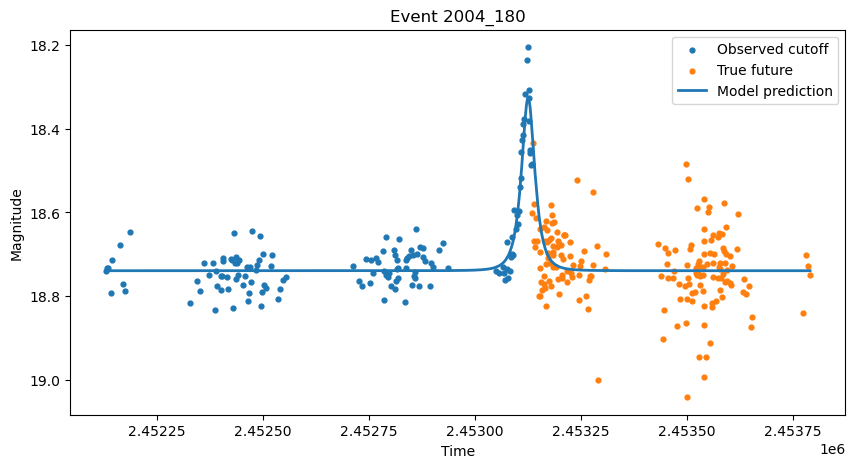


[2/50] Fitting 2004_181


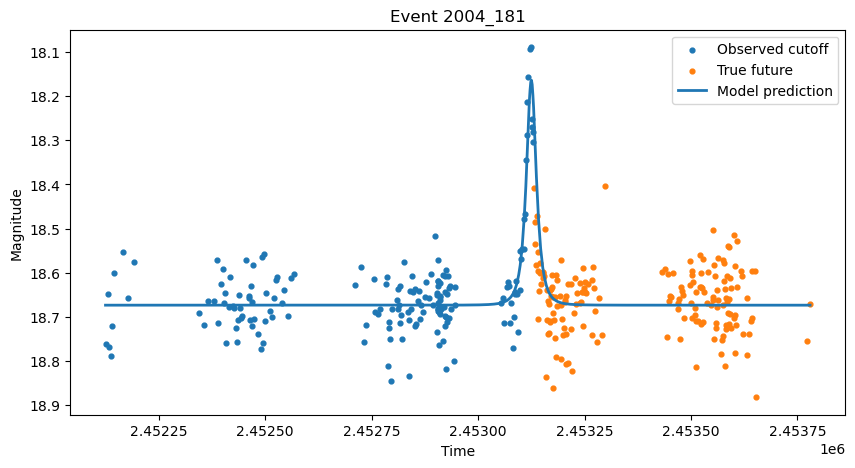


[3/50] Fitting 2004_191


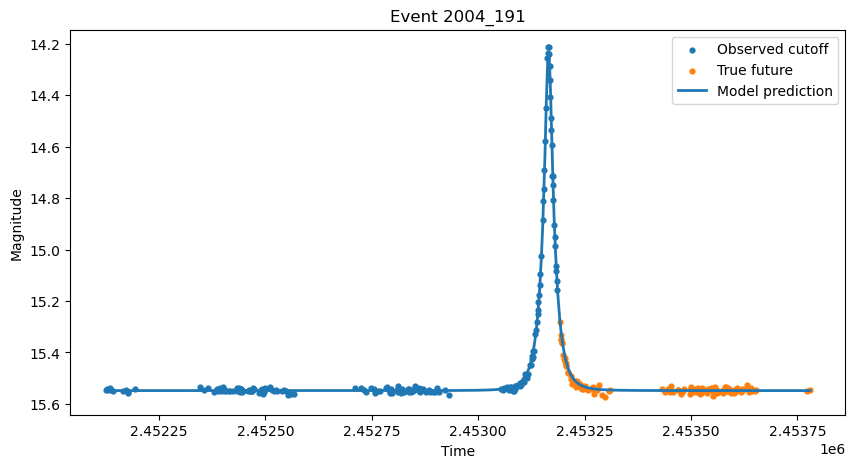


[4/50] Fitting 2004_193


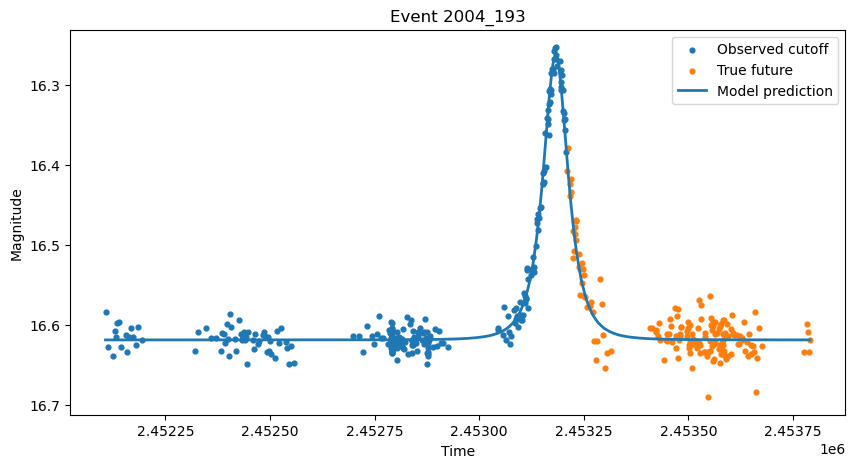


[5/50] Fitting 2004_196


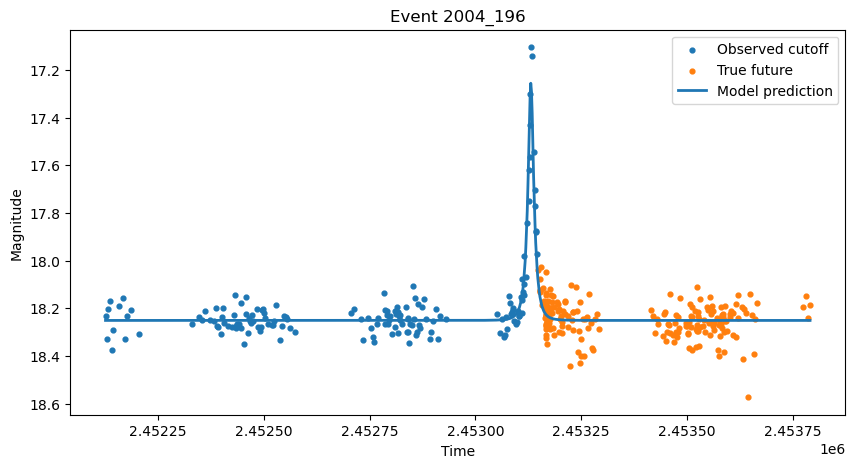


[6/50] Fitting 2004_199

[7/50] Fitting 2004_202

[8/50] Fitting 2004_203

[9/50] Fitting 2004_214

[10/50] Fitting 2004_223

[11/50] Fitting 2011_0086

[12/50] Fitting 2011_0122

[13/50] Fitting 2011_0136

[14/50] Fitting 2011_0183

[15/50] Fitting 2011_0192

[16/50] Fitting 2011_0241

[17/50] Fitting 2011_0260

[18/50] Fitting 2011_0636

[19/50] Fitting 2011_1131

[20/50] Fitting 2012_0002

[21/50] Fitting 2014_0007

[22/50] Fitting 2014_0020

[23/50] Fitting 2014_0044

[24/50] Fitting 2014_0060

[25/50] Fitting 2014_0094

[26/50] Fitting 2014_0117

[27/50] Fitting 2014_0132

[28/50] Fitting 2014_0158

[29/50] Fitting 2014_0190

[30/50] Fitting 2014_0207

[31/50] Fitting 2018_0054

[32/50] Fitting 2018_0199

[33/50] Fitting 2018_0258

[34/50] Fitting 2018_0270

[35/50] Fitting 2018_0297

[36/50] Fitting 2018_0328

[37/50] Fitting 2018_0340

[38/50] Fitting 2018_0365

[39/50] Fitting 2018_0405

[40/50] Fitting 2018_0503

[41/50] Fitting 2024_012

[42/50] Fitting 2024_031

[43/50] Fit

,event_id,year,cutoff_file,full_file,params_file,final_loss,obs_mae,obs_rmse,all_mae,all_rmse,...,true_param_7,true_param_8,true_param_9,true_param_10,true_param_11,true_param_12,true_param_13,true_param_14,true_param_15,true_param_16
0,2004_180,2004,curve_2004_180_cutoff.dat,2004/curve_2004_180.dat,2004/params_2004_180.dat,0.002095,0.036516,0.045775,0.052562,0.073025,...,1.542,0.025,0.470,0.002,1.000,0.000,18.728,0.003,18.728,0.003
1,2004_181,2004,curve_2004_181_cutoff.dat,2004/curve_2004_181.dat,2004/params_2004_181.dat,0.003625,0.047109,0.060207,0.054376,0.071424,...,1.780,0.045,0.626,0.002,1.000,0.000,18.659,0.003,18.659,0.003
2,2004_191,2004,curve_2004_191_cutoff.dat,2004/curve_2004_191.dat,2004/params_2004_191.dat,0.000364,0.011497,0.019088,0.009837,0.015919,...,3.533,0.035,1.370,0.000,0.954,0.013,15.548,0.000,15.599,0.015
3,2004_193,2004,curve_2004_193_cutoff.dat,2004/curve_2004_193.dat,2004/params_2004_193.dat,0.000170,0.010260,0.013030,0.012340,0.016303,...,1.386,0.002,0.354,0.000,1.000,0.000,16.617,0.001,16.617,0.001
4,2004_196,2004,curve_2004_196_cutoff.dat,2004/curve_2004_196.dat,2004/params_2004_196.dat,0.003736,0.045351,0.061122,0.048213,0.064852,...,8.805,1.067,2.362,0.000,0.301,0.034,18.248,0.002,19.551,0.126



Overall summary:


,obs_mae,obs_rmse,all_mae,all_rmse,future_mae,future_rmse,future_r2
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.042695,0.055833,0.048063,0.066975,0.063840,0.085223,0.405207
std,0.037428,0.047066,0.040292,0.058338,0.075613,0.099823,0.554096
min,0.005689,0.007470,0.006114,0.008315,0.006979,0.009813,-1.478637
25%,0.013206,0.018105,0.015085,0.021935,0.023419,0.030857,0.028335
50%,0.035703,0.045547,0.039724,0.052853,0.043845,0.059116,0.508167
75%,0.056812,0.073858,0.062494,0.082289,0.072155,0.094687,0.881527
max,0.176634,0.224641,0.174010,0.265756,0.469224,0.562078,0.992335



By-year summary:


,future_mae,future_rmse,future_r2
year,,,
2004,0.043150,0.057953,0.489209
2011,0.035977,0.045088,0.906011
2012,0.023277,0.030392,0.966654
2014,0.134661,0.183236,-0.092417
2018,0.064263,0.083799,0.219146
2024,0.042420,0.057511,0.498021



Failures:


""



Saved files:
parameter_comparison_table.csv
parameter_summary_overall.csv
parameter_summary_by_year.csv


In [1]:
# ============================
# ULAB MICROLENSING BATCH MODEL
# One-cell version
# ============================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim


# ============================
# CONFIG
# ============================

# If this notebook is INSIDE the testing folder, use:
BASE_DIR = Path(".")

# If this notebook is OUTSIDE the testing folder, use:
# BASE_DIR = Path("testing")

LIMIT = None          # Use 3 or 5 first for quick testing; use None for all
NUM_EPOCHS = 3000
LR = 0.01
PLOT_FIRST_N = 5      # Plots first few fitted events

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================
# FILE HELPERS
# ============================

def extract_event_id(filename):
    """
    Examples:
    curve_2014_0190_cutoff.dat -> 2014_0190
    curve_2014_0190.dat        -> 2014_0190
    params_2014_0190.dat       -> 2014_0190
    curve_2004_180_cutoff.dat  -> 2004_180
    """
    name = Path(filename).name
    match = re.search(r"(20\d{2}_\d+)", name)
    if match is None:
        return None
    return match.group(1)


def find_event_triplets(base_dir):
    """
    Finds matching:
      cutoff file in main folder
      full curve in year subfolder
      params file in year subfolder
    """
    base_dir = Path(base_dir)

    cutoff_files = list(base_dir.glob("curve_*_cutoff.dat"))
    full_curve_files = list(base_dir.glob("*/curve_*.dat"))
    param_files = list(base_dir.glob("*/params_*.dat"))

    # Remove accidental cutoff files from full curve list if any are inside subfolders
    full_curve_files = [f for f in full_curve_files if "_cutoff" not in f.name]

    full_by_id = {
        extract_event_id(f): f
        for f in full_curve_files
        if extract_event_id(f) is not None
    }

    params_by_id = {
        extract_event_id(f): f
        for f in param_files
        if extract_event_id(f) is not None
    }

    triplets = []

    for cutoff in cutoff_files:
        event_id = extract_event_id(cutoff)

        if event_id in full_by_id and event_id in params_by_id:
            year = int(event_id.split("_")[0])
            triplets.append({
                "event_id": event_id,
                "year": year,
                "cutoff_file": cutoff,
                "full_file": full_by_id[event_id],
                "params_file": params_by_id[event_id],
            })

    triplets = sorted(triplets, key=lambda x: x["event_id"])

    if LIMIT is not None:
        triplets = triplets[:LIMIT]

    print(f"Found cutoff files: {len(cutoff_files)}")
    print(f"Found full curve files: {len(full_curve_files)}")
    print(f"Found params files: {len(param_files)}")
    print(f"Matched complete triplets: {len(triplets)}")

    if len(triplets) == 0:
        print("\nNo complete triplets found.")
        print("Check whether BASE_DIR is correct.")
        print("Current BASE_DIR:", base_dir.resolve())

    return triplets


def robust_load_dat(path):
    """
    Loads .dat files robustly.
    Assumes first two numerical columns are time and magnitude.
    Ignores bad/comment rows.
    """
    rows = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if len(line) == 0:
                continue

            if line.startswith("#"):
                continue

            parts = line.split()

            try:
                nums = [float(x) for x in parts]
                if len(nums) >= 2:
                    rows.append(nums)
            except:
                continue

    if len(rows) == 0:
        raise ValueError(f"No numerical data found in {path}")

    return np.array(rows, dtype=float)


def load_true_params(path):
    """
    Loads params file flexibly.
    Since params files can vary, this returns numbered params if names are unclear.
    """
    vals = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if len(line) == 0 or line.startswith("#"):
                continue

            parts = line.split()

            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass

    true_params = {}

    for i, v in enumerate(vals):
        true_params[f"param_{i}"] = v

    return true_params


# ============================
# MICROLENSING MODEL
# ============================

class MicrolensingModel(nn.Module):
    """
    Physics-based Paczynski microlensing light curve model.

    This is NOT a neural network that learns from many curves.
    It is a differentiable physics model whose parameters are optimized
    separately for each event using PyTorch gradient descent.
    """

    def __init__(self, t_obs, m_obs):
        super().__init__()

        t_obs = np.asarray(t_obs)
        m_obs = np.asarray(m_obs)

        # Good starting guesses
        baseline_guess = np.median(m_obs)

        # In magnitude space, smaller value = brighter
        peak_idx = np.argmin(m_obs)
        t0_guess = t_obs[peak_idx]

        t_range = max(t_obs.max() - t_obs.min(), 1.0)
        tau_guess = max(t_range / 5, 1.0)

        # Parameters are stored in transformed ways to keep them valid
        self.t0 = nn.Parameter(torch.tensor(float(t0_guess), dtype=torch.float32))
        self.log_tE = nn.Parameter(torch.tensor(np.log(tau_guess), dtype=torch.float32))
        self.log_u0 = nn.Parameter(torch.tensor(np.log(0.5), dtype=torch.float32))
        self.I0 = nn.Parameter(torch.tensor(float(baseline_guess), dtype=torch.float32))
        self.fbl_raw = nn.Parameter(torch.tensor(2.0, dtype=torch.float32))

    def forward(self, t):
        tE = torch.exp(self.log_tE) + 1e-6
        u0 = torch.exp(self.log_u0) + 1e-6
        fbl = torch.sigmoid(self.fbl_raw)

        u = torch.sqrt(u0 ** 2 + ((t - self.t0) / tE) ** 2 + 1e-8)

        A = (u ** 2 + 2) / (u * torch.sqrt(u ** 2 + 4))

        flux_factor = fbl * A + (1 - fbl)

        mag = self.I0 - 2.5 * torch.log10(flux_factor + 1e-8)

        return mag

    def get_params(self):
        with torch.no_grad():
            return {
                "t0": float(self.t0.cpu()),
                "tE": float(torch.exp(self.log_tE).cpu()),
                "u0": float(torch.exp(self.log_u0).cpu()),
                "I0": float(self.I0.cpu()),
                "fbl": float(torch.sigmoid(self.fbl_raw).cpu()),
            }


# ============================
# EVENT PREP / FIT / EVAL
# ============================

def prepare_single_event(cutoff_file, full_file):
    cutoff_data = robust_load_dat(cutoff_file)
    full_data = robust_load_dat(full_file)

    t_obs = cutoff_data[:, 0]
    m_obs = cutoff_data[:, 1]

    t_all = full_data[:, 0]
    m_all = full_data[:, 1]

    cutoff_end = t_obs.max()

    future_mask = t_all > cutoff_end

    t_future = t_all[future_mask]
    m_future = m_all[future_mask]

    return {
        "t_obs": t_obs,
        "m_obs": m_obs,
        "t_all": t_all,
        "m_all": m_all,
        "t_future": t_future,
        "m_future": m_future,
        "cutoff_end": cutoff_end,
    }


def fit_single_event(event_dict, num_epochs=3000, lr=0.01, verbose=False):
    t_obs = event_dict["t_obs"]
    m_obs = event_dict["m_obs"]

    model = MicrolensingModel(t_obs, m_obs).to(device)

    t_tensor = torch.tensor(t_obs, dtype=torch.float32, device=device)
    m_tensor = torch.tensor(m_obs, dtype=torch.float32, device=device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    loss_history = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()

        pred = model(t_tensor)
        loss = loss_fn(pred, m_tensor)

        # Small regularization to avoid insane parameter values
        params = model.get_params()
        reg = 0.0

        loss.backward()
        optimizer.step()

        loss_history.append(float(loss.detach().cpu()))

        if verbose and epoch % 500 == 0:
            print(f"Epoch {epoch}: loss = {loss_history[-1]:.6f}")

    return model, model.get_params(), loss_history


def evaluate_event(model, event_dict):
    t_obs = event_dict["t_obs"]
    m_obs = event_dict["m_obs"]
    t_future = event_dict["t_future"]
    m_future = event_dict["m_future"]
    t_all = event_dict["t_all"]
    m_all = event_dict["m_all"]

    metrics = {}

    with torch.no_grad():
        # Observed-region prediction
        t_obs_tensor = torch.tensor(t_obs, dtype=torch.float32, device=device)
        pred_obs = model(t_obs_tensor).cpu().numpy()

        obs_mae = np.mean(np.abs(pred_obs - m_obs))
        obs_rmse = np.sqrt(np.mean((pred_obs - m_obs) ** 2))

        metrics["obs_mae"] = obs_mae
        metrics["obs_rmse"] = obs_rmse

        # Full-curve prediction
        t_all_tensor = torch.tensor(t_all, dtype=torch.float32, device=device)
        pred_all = model(t_all_tensor).cpu().numpy()

        all_mae = np.mean(np.abs(pred_all - m_all))
        all_rmse = np.sqrt(np.mean((pred_all - m_all) ** 2))

        metrics["all_mae"] = all_mae
        metrics["all_rmse"] = all_rmse

        # Future-region prediction
        if len(t_future) > 0:
            t_future_tensor = torch.tensor(t_future, dtype=torch.float32, device=device)
            pred_future = model(t_future_tensor).cpu().numpy()

            future_mae = np.mean(np.abs(pred_future - m_future))
            future_rmse = np.sqrt(np.mean((pred_future - m_future) ** 2))

            ss_res = np.sum((m_future - pred_future) ** 2)
            ss_tot = np.sum((m_future - np.mean(m_future)) ** 2)

            if ss_tot > 0:
                future_r2 = 1 - ss_res / ss_tot
            else:
                future_r2 = np.nan

            metrics["future_mae"] = future_mae
            metrics["future_rmse"] = future_rmse
            metrics["future_r2"] = future_r2
            metrics["num_future_points"] = len(t_future)
        else:
            metrics["future_mae"] = np.nan
            metrics["future_rmse"] = np.nan
            metrics["future_r2"] = np.nan
            metrics["num_future_points"] = 0

    return metrics


def plot_event_fit(model, event_dict, title):
    t_obs = event_dict["t_obs"]
    m_obs = event_dict["m_obs"]
    t_future = event_dict["t_future"]
    m_future = event_dict["m_future"]
    t_all = event_dict["t_all"]
    m_all = event_dict["m_all"]

    t_grid = np.linspace(t_all.min(), t_all.max(), 1000)

    with torch.no_grad():
        t_grid_tensor = torch.tensor(t_grid, dtype=torch.float32, device=device)
        pred_grid = model(t_grid_tensor).cpu().numpy()

    plt.figure(figsize=(10, 5))
    plt.scatter(t_obs, m_obs, s=12, label="Observed cutoff")
    plt.scatter(t_future, m_future, s=12, label="True future")
    plt.plot(t_grid, pred_grid, linewidth=2, label="Model prediction")

    # Magnitudes are inverted: lower = brighter
    plt.gca().invert_yaxis()

    plt.xlabel("Time")
    plt.ylabel("Magnitude")
    plt.title(title)
    plt.legend()
    plt.show()


# ============================
# BATCH RUNNER
# ============================

def run_batch_parameter_table():
    triplets = find_event_triplets(BASE_DIR)

    all_rows = []
    failures = []

    for i, item in enumerate(triplets):
        event_id = item["event_id"]
        year = item["year"]
        cutoff_file = item["cutoff_file"]
        full_file = item["full_file"]
        params_file = item["params_file"]

        print(f"\n[{i+1}/{len(triplets)}] Fitting {event_id}")

        try:
            event_dict = prepare_single_event(cutoff_file, full_file)

            model, fitted_params, loss_history = fit_single_event(
                event_dict,
                num_epochs=NUM_EPOCHS,
                lr=LR,
                verbose=False,
            )

            metrics = evaluate_event(model, event_dict)
            true_params = load_true_params(params_file)

            row = {
                "event_id": event_id,
                "year": year,
                "cutoff_file": str(cutoff_file),
                "full_file": str(full_file),
                "params_file": str(params_file),
                "final_loss": loss_history[-1],
                **metrics,
            }

            for k, v in fitted_params.items():
                row[f"fit_{k}"] = v

            for k, v in true_params.items():
                row[f"true_{k}"] = v

            all_rows.append(row)

            if i < PLOT_FIRST_N:
                plot_event_fit(model, event_dict, title=f"Event {event_id}")

        except Exception as e:
            print(f"FAILED {event_id}: {e}")
            failures.append({
                "event_id": event_id,
                "error": str(e),
                "cutoff_file": str(cutoff_file),
                "full_file": str(full_file),
                "params_file": str(params_file),
            })

    results_df = pd.DataFrame(all_rows)
    failures_df = pd.DataFrame(failures)

    if len(results_df) > 0:
        results_df.to_csv("parameter_comparison_table.csv", index=False)

        overall_summary = results_df[
            ["obs_mae", "obs_rmse", "all_mae", "all_rmse", "future_mae", "future_rmse", "future_r2"]
        ].describe()

        overall_summary.to_csv("parameter_summary_overall.csv")

        by_year_summary = results_df.groupby("year")[
            ["future_mae", "future_rmse", "future_r2"]
        ].mean()

        by_year_summary.to_csv("parameter_summary_by_year.csv")

    else:
        overall_summary = pd.DataFrame()
        by_year_summary = pd.DataFrame()

    if len(failures_df) > 0:
        failures_df.to_csv("failed_events.csv", index=False)

    return results_df, failures_df, overall_summary, by_year_summary


# ============================
# ACTUALLY RUN EVERYTHING
# ============================

results_df, failures_df, overall_summary, by_year_summary = run_batch_parameter_table()

print("\n============================")
print("DONE")
print("============================")

print("\nResults:")
display(results_df.head())

print("\nOverall summary:")
display(overall_summary)

print("\nBy-year summary:")
display(by_year_summary)

print("\nFailures:")
display(failures_df)

print("\nSaved files:")
print("parameter_comparison_table.csv")
print("parameter_summary_overall.csv")
print("parameter_summary_by_year.csv")
if len(failures_df) > 0:
    print("failed_events.csv")

ALL EVENTS RANKED BY FUTURE R²
Higher future_r2 = better extrapolation


,event_id,year,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_t0,fit_tE,fit_u0,fit_I0,fit_fbl
0,2011_0241,2011,0.992335,0.006979,0.009813,0.005689,0.007470,0.006114,0.008315,0.000056,2455726.75,40.199059,0.868890,15.700536,0.790754
1,2004_203,2004,0.987414,0.009947,0.012315,0.009437,0.013323,0.009607,0.012994,0.000177,2453218.50,52.312340,0.130713,15.947216,0.794966
2,2011_0136,2011,0.977152,0.007280,0.010573,0.006493,0.008274,0.006913,0.009570,0.000068,2455650.00,9.292787,0.527754,15.389925,0.825255
3,2011_0260,2011,0.971399,0.037087,0.049494,0.029774,0.037925,0.032465,0.042550,0.001438,2455698.75,27.354624,0.145038,18.298658,0.948465
4,2012_0002,2012,0.966654,0.023277,0.030392,0.018211,0.023944,0.019957,0.026345,0.000573,2455999.75,35.314449,0.389529,17.015955,0.781840
5,2018_0199,2018,0.959069,0.030967,0.038562,0.017292,0.021205,0.021331,0.027497,0.000450,2458230.75,56.570015,0.429490,16.936693,0.797907
6,2004_191,2004,0.953117,0.007694,0.010494,0.011497,0.019088,0.009837,0.015919,0.000364,2453165.50,28.304981,0.258064,15.548236,0.795773
7,2011_0122,2011,0.926928,0.091384,0.103042,0.012490,0.016552,0.047780,0.070006,0.000274,2455665.75,71.448586,0.201199,17.408581,0.948313
8,2024_156,2024,0.920014,0.085154,0.133773,0.008923,0.034716,0.013575,0.047156,0.001205,2460515.75,114.526047,0.085835,13.172354,0.672141
9,2024_056,2024,0.919990,0.030311,0.041738,0.033113,0.043562,0.032830,0.043381,0.001898,2460436.75,88.759155,0.473976,18.420914,0.778427



TOP EVENTS BY FUTURE R²


,event_id,year,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_t0,fit_tE,fit_u0,fit_I0,fit_fbl
0,2011_0241,2011,0.992335,0.006979,0.009813,0.005689,0.007470,0.006114,0.008315,0.000056,2455726.75,40.199059,0.868890,15.700536,0.790754
1,2004_203,2004,0.987414,0.009947,0.012315,0.009437,0.013323,0.009607,0.012994,0.000177,2453218.50,52.312340,0.130713,15.947216,0.794966
2,2011_0136,2011,0.977152,0.007280,0.010573,0.006493,0.008274,0.006913,0.009570,0.000068,2455650.00,9.292787,0.527754,15.389925,0.825255
3,2011_0260,2011,0.971399,0.037087,0.049494,0.029774,0.037925,0.032465,0.042550,0.001438,2455698.75,27.354624,0.145038,18.298658,0.948465
4,2012_0002,2012,0.966654,0.023277,0.030392,0.018211,0.023944,0.019957,0.026345,0.000573,2455999.75,35.314449,0.389529,17.015955,0.781840



WORST EVENTS BY FUTURE R²


...


CORRELATION TABLE
Useful for seeing what predicts bad future performance


,future_r2,future_mae,future_rmse,obs_mae,obs_rmse,all_mae,all_rmse,final_loss,fit_tE,fit_u0,fit_fbl
future_r2,1.000000,-0.668179,-0.647088,-0.516019,-0.513300,-0.632041,-0.664843,-0.366686,-0.192301,-0.246314,0.200111
future_mae,-0.668179,1.000000,0.980303,0.542575,0.553671,0.778742,0.891935,0.446627,0.416373,0.173968,-0.152635
future_rmse,-0.647088,0.980303,1.000000,0.522966,0.535862,0.753841,0.892444,0.424818,0.467829,0.282215,-0.177561
obs_mae,-0.516019,0.542575,0.522966,1.000000,0.997083,0.943132,0.844816,0.936252,0.074691,-0.177689,0.065014
obs_rmse,-0.513300,0.553671,0.535862,0.997083,1.000000,0.942031,0.849745,0.933592,0.101036,-0.191325,0.044301
all_mae,-0.632041,0.778742,0.753841,0.943132,0.942031,1.000000,0.966142,0.855953,0.200491,-0.071892,0.025301
all_rmse,-0.664843,0.891935,0.892444,0.844816,0.849745,0.966142,1.000000,0.748952,0.316314,0.071837,-0.041914
final_loss,-0.366686,0.446627,0.424818,0.936252,0.933592,0.855953,0.748952,1.000000,0.003734,-0.176305,0.084516
fit_tE,-0.192301,0.416373,0.467829,0.074691,0.101036,0.200491,0.316314,0.003734,1.000000,0.314366,-0.644964
fit_u0,-0.246314,0.173968,0.282215,-0.177689,-0.191325,-0.071892,0.071837,-0.176305,0.314366,1.000000,-0.395658



Most relevant correlations with future_r2:


,correlation_with_future_r2
future_mae,-0.668179
all_rmse,-0.664843
future_rmse,-0.647088
all_mae,-0.632041
obs_mae,-0.516019
obs_rmse,-0.513300
final_loss,-0.366686
fit_u0,-0.246314
fit_tE,-0.192301
fit_fbl,0.200111



Saved deeper analysis CSVs:
deep_ranked_by_future_r2.csv
deep_ranked_by_future_mae.csv
deep_worst_by_future_r2.csv
deep_worst_by_future_mae.csv
deep_summary_stats.csv
deep_year_summary.csv
deep_correlation_table.csv
deep_r2_outliers.csv
deep_mae_outliers.csv


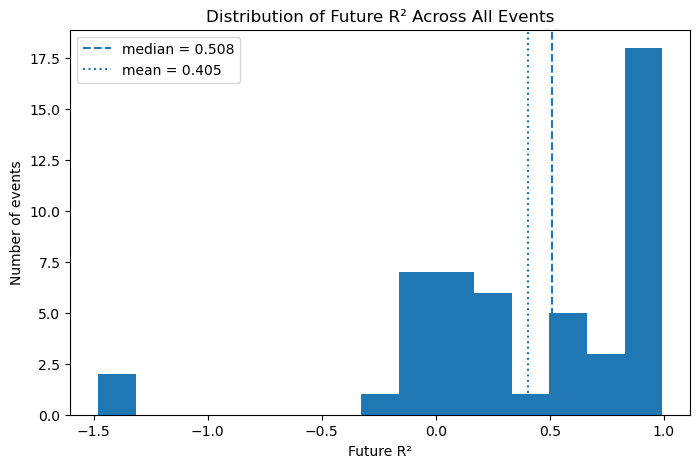

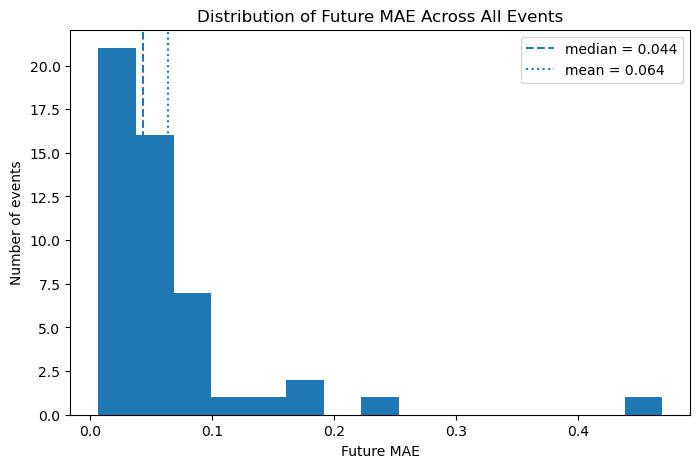

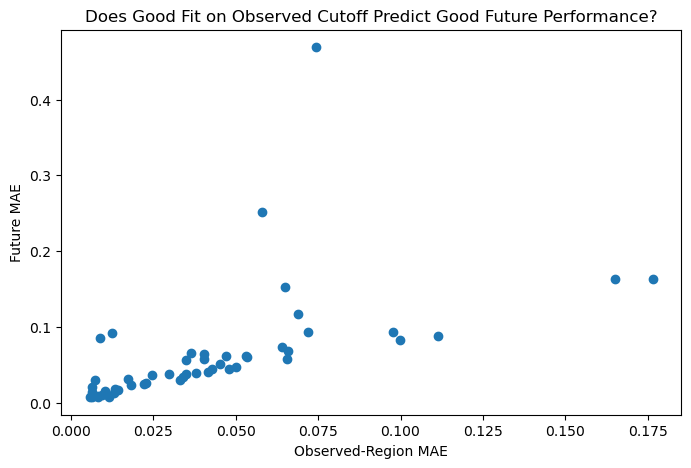

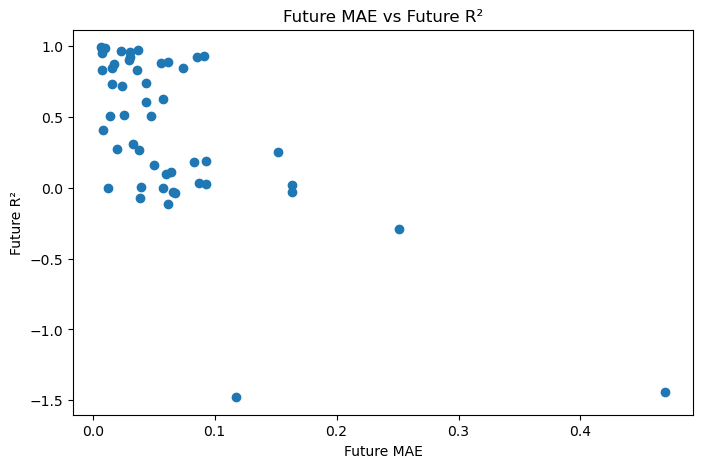

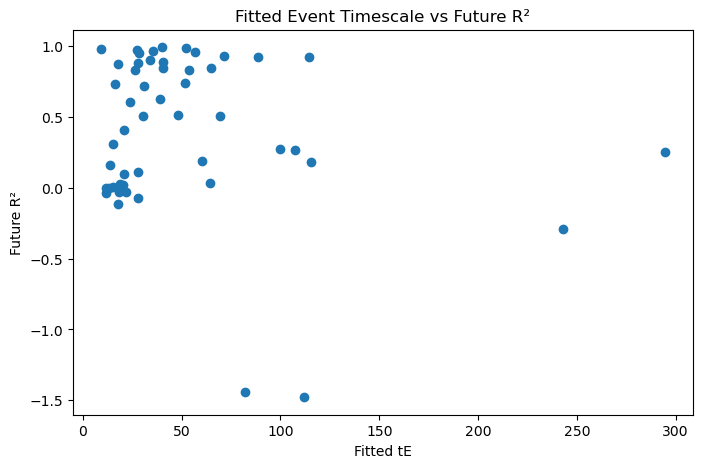

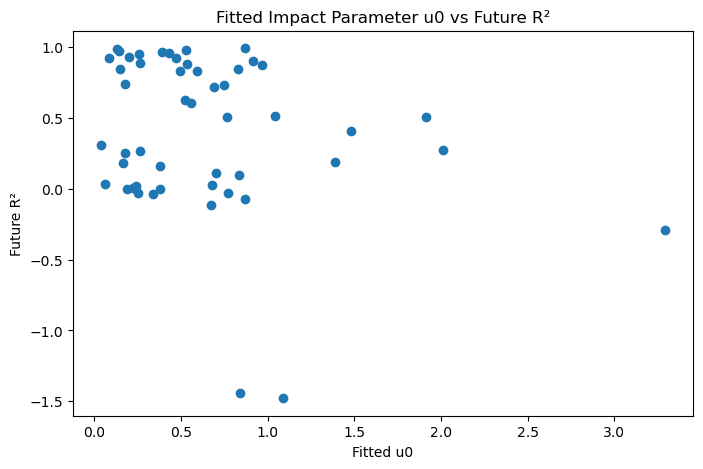


PLOTTING TOP 5 EVENTS BY FUTURE R²


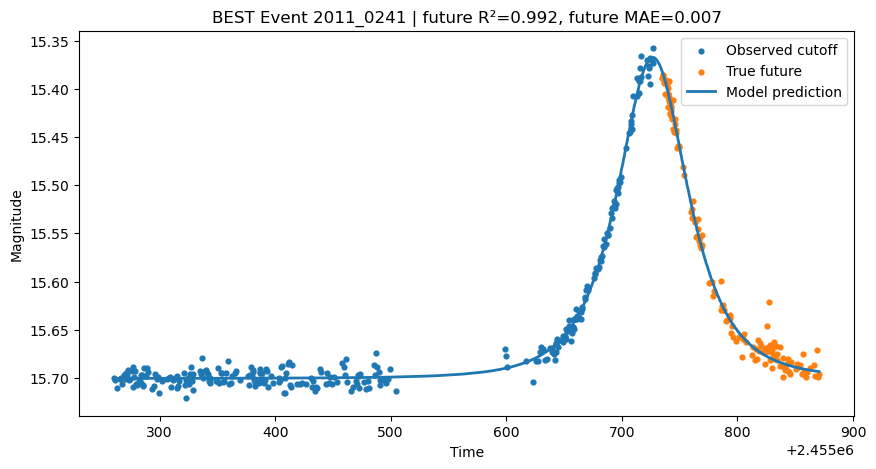

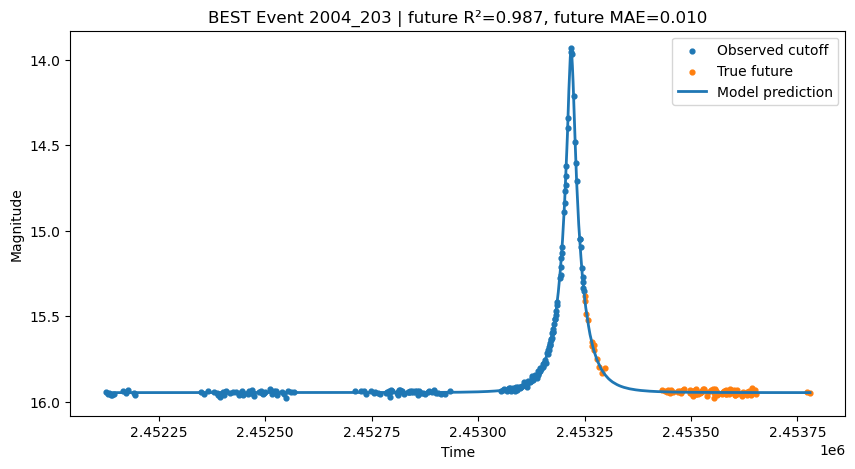

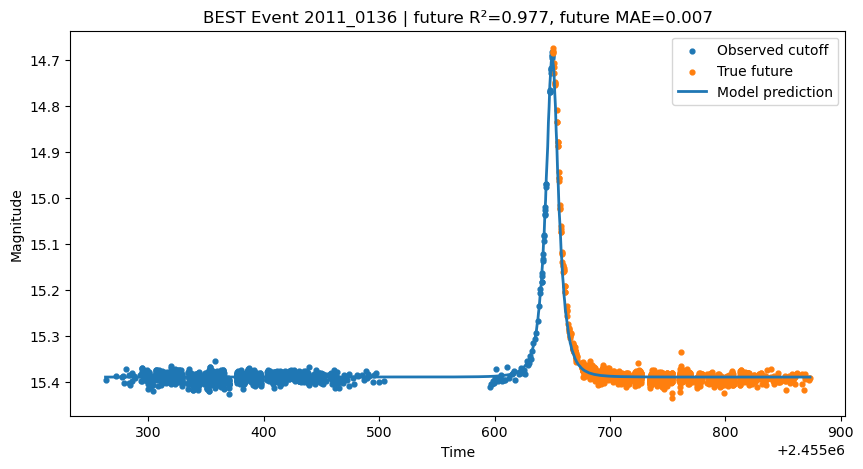

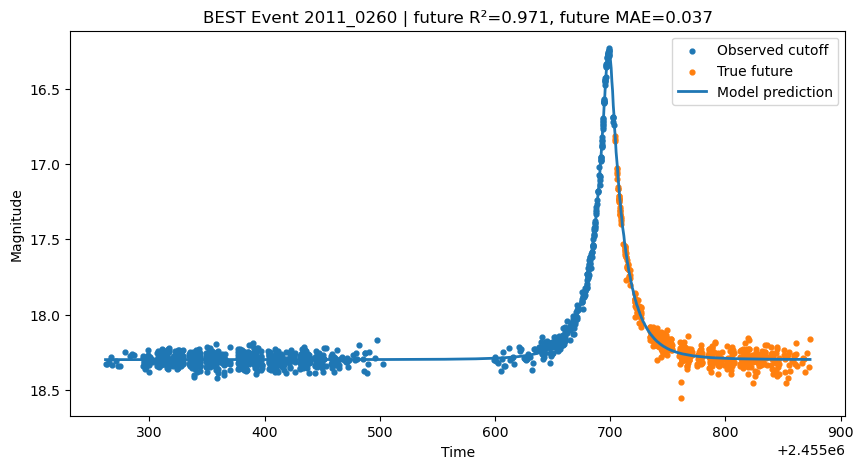

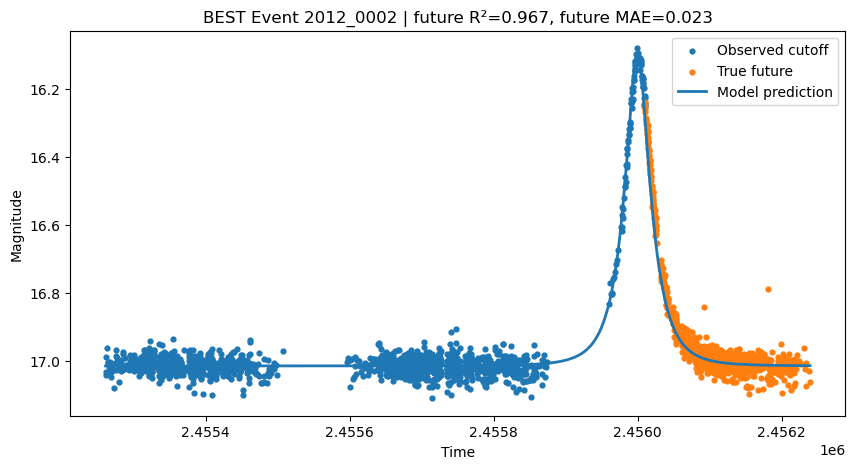


PLOTTING WORST 5 EVENTS BY FUTURE R²


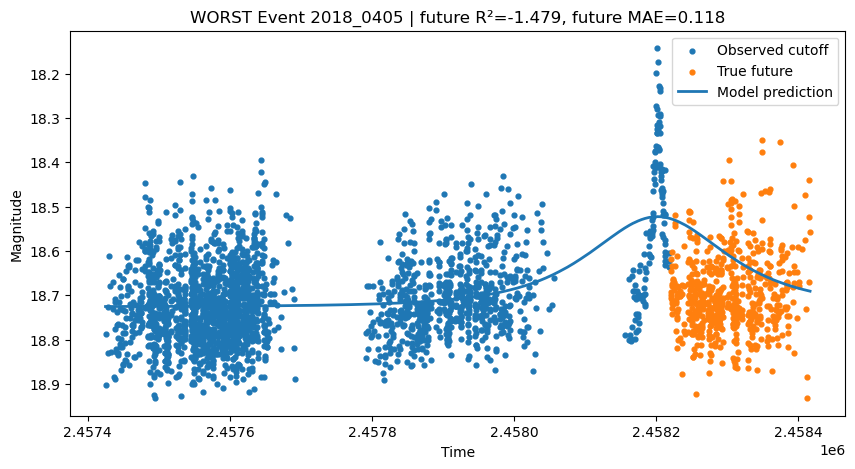

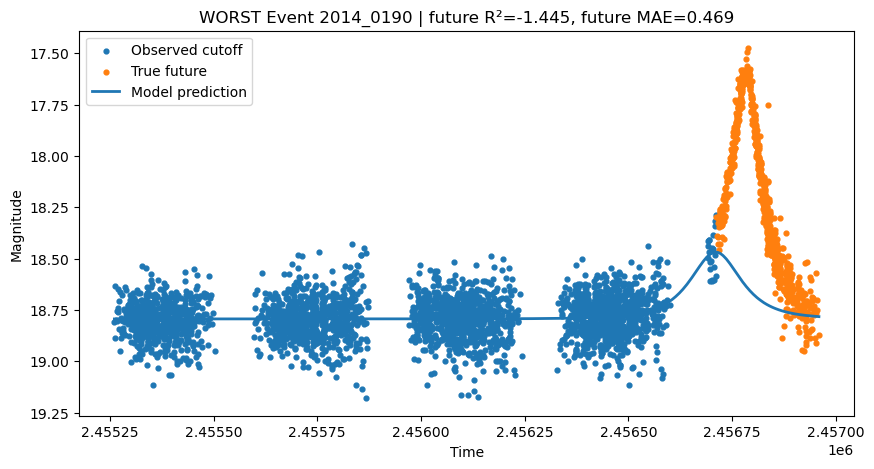

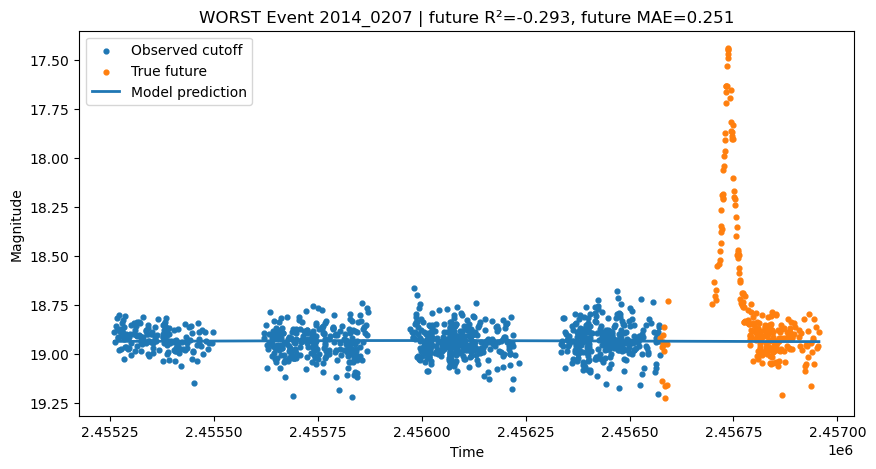

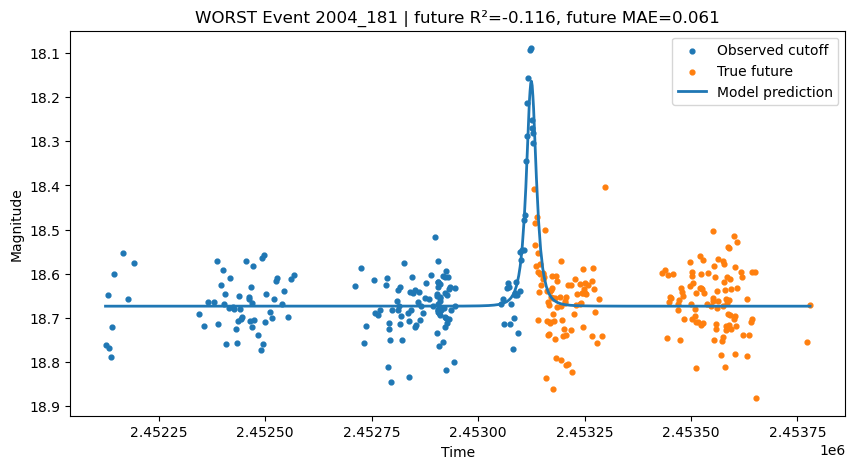

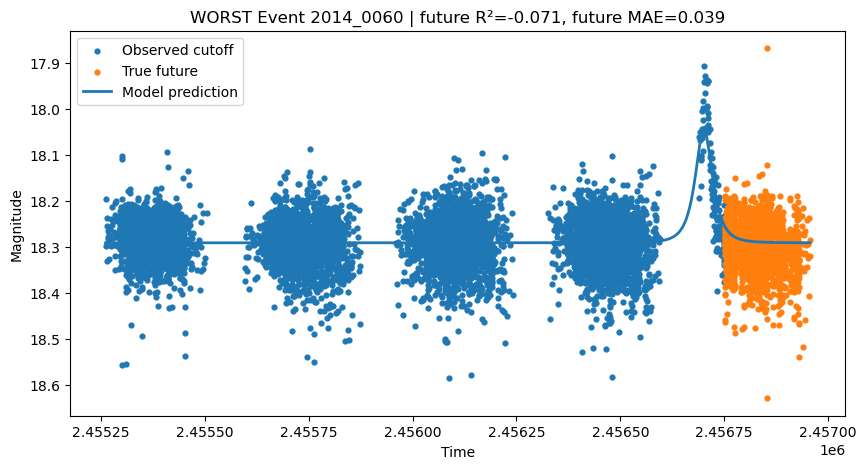


DEEP ANALYSIS DONE


In [2]:
# ============================
# DEEPER ANALYSIS CELL
# Run this AFTER the batch model cell
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------

N_BEST = 5
N_WORST = 5
N_OUTLIERS = 10

# If you want fewer plots, lower these.
PLOT_BEST = True
PLOT_WORST = True

# ----------------------------
# SAFETY CHECKS
# ----------------------------

if "results_df" not in globals():
    raise RuntimeError("results_df not found. Run the main batch cell first.")

if len(results_df) == 0:
    raise RuntimeError("results_df is empty. The batch run did not produce results.")

df = results_df.copy()

# Make sure key columns are numeric
numeric_cols = [
    "obs_mae", "obs_rmse",
    "all_mae", "all_rmse",
    "future_mae", "future_rmse", "future_r2",
    "final_loss",
    "fit_t0", "fit_tE", "fit_u0", "fit_I0", "fit_fbl",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ----------------------------
# BASIC RANKED TABLES
# ----------------------------

ranked_by_r2 = df.sort_values("future_r2", ascending=False).reset_index(drop=True)
ranked_by_mae = df.sort_values("future_mae", ascending=True).reset_index(drop=True)
worst_by_r2 = df.sort_values("future_r2", ascending=True).reset_index(drop=True)
worst_by_mae = df.sort_values("future_mae", ascending=False).reset_index(drop=True)

print("================================")
print("ALL EVENTS RANKED BY FUTURE R²")
print("Higher future_r2 = better extrapolation")
print("================================")

display_cols = [
    "event_id", "year",
    "future_r2", "future_mae", "future_rmse",
    "obs_mae", "obs_rmse",
    "all_mae", "all_rmse",
    "final_loss",
    "fit_t0", "fit_tE", "fit_u0", "fit_I0", "fit_fbl",
]

display_cols = [c for c in display_cols if c in df.columns]

display(ranked_by_r2[display_cols])

print("\n================================")
print("TOP EVENTS BY FUTURE R²")
print("================================")
display(ranked_by_r2.head(N_BEST)[display_cols])

print("\n================================")
print("WORST EVENTS BY FUTURE R²")
print("================================")
display(worst_by_r2.head(N_WORST)[display_cols])

print("\n================================")
print("BEST EVENTS BY FUTURE MAE")
print("Lower future_mae = better absolute magnitude error")
print("================================")
display(ranked_by_mae.head(N_BEST)[display_cols])

print("\n================================")
print("WORST EVENTS BY FUTURE MAE")
print("================================")
display(worst_by_mae.head(N_WORST)[display_cols])


# ----------------------------
# SUMMARY STATS
# ----------------------------

summary_metrics = [
    "obs_mae", "obs_rmse",
    "all_mae", "all_rmse",
    "future_mae", "future_rmse", "future_r2",
]

summary_metrics = [c for c in summary_metrics if c in df.columns]

deep_summary = df[summary_metrics].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    lambda x: x.quantile(0.10),
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    lambda x: x.quantile(0.90),
    "max",
])

deep_summary.index = [
    "count",
    "mean",
    "median",
    "std",
    "min",
    "10%",
    "25%",
    "75%",
    "90%",
    "max",
]

print("\n================================")
print("DEEP SUMMARY STATS")
print("================================")
display(deep_summary)


# ----------------------------
# R² DISTRIBUTION COUNTS
# ----------------------------

def r2_bucket(r2):
    if pd.isna(r2):
        return "NaN"
    elif r2 >= 0.90:
        return "excellent: R² >= 0.90"
    elif r2 >= 0.75:
        return "strong: 0.75 <= R² < 0.90"
    elif r2 >= 0.50:
        return "decent: 0.50 <= R² < 0.75"
    elif r2 >= 0.00:
        return "weak: 0.00 <= R² < 0.50"
    else:
        return "bad: R² < 0"

df["r2_bucket"] = df["future_r2"].apply(r2_bucket)

r2_bucket_counts = (
    df["r2_bucket"]
    .value_counts()
    .reindex([
        "excellent: R² >= 0.90",
        "strong: 0.75 <= R² < 0.90",
        "decent: 0.50 <= R² < 0.75",
        "weak: 0.00 <= R² < 0.50",
        "bad: R² < 0",
        "NaN",
    ])
    .dropna()
)

print("\n================================")
print("FUTURE R² BUCKET COUNTS")
print("================================")
display(r2_bucket_counts.to_frame("count"))


# ----------------------------
# OUTLIER DETECTION
# ----------------------------

r2_q1 = df["future_r2"].quantile(0.25)
r2_q3 = df["future_r2"].quantile(0.75)
r2_iqr = r2_q3 - r2_q1
r2_lower_fence = r2_q1 - 1.5 * r2_iqr

mae_q1 = df["future_mae"].quantile(0.25)
mae_q3 = df["future_mae"].quantile(0.75)
mae_iqr = mae_q3 - mae_q1
mae_upper_fence = mae_q3 + 1.5 * mae_iqr

r2_outliers = df[df["future_r2"] < r2_lower_fence].sort_values("future_r2")
mae_outliers = df[df["future_mae"] > mae_upper_fence].sort_values("future_mae", ascending=False)

print("\n================================")
print("R² OUTLIER THRESHOLD")
print("================================")
print(f"R² Q1: {r2_q1:.4f}")
print(f"R² Q3: {r2_q3:.4f}")
print(f"R² IQR: {r2_iqr:.4f}")
print(f"Lower outlier fence: {r2_lower_fence:.4f}")

print("\nBad R² outliers:")
display(r2_outliers[display_cols])

print("\n================================")
print("FUTURE MAE OUTLIER THRESHOLD")
print("================================")
print(f"Future MAE Q1: {mae_q1:.4f}")
print(f"Future MAE Q3: {mae_q3:.4f}")
print(f"Future MAE IQR: {mae_iqr:.4f}")
print(f"Upper outlier fence: {mae_upper_fence:.4f}")

print("\nHigh future MAE outliers:")
display(mae_outliers[display_cols])


# ----------------------------
# YEAR-BY-YEAR DEEP SUMMARY
# ----------------------------

year_summary = df.groupby("year").agg(
    n=("event_id", "count"),
    median_future_r2=("future_r2", "median"),
    mean_future_r2=("future_r2", "mean"),
    min_future_r2=("future_r2", "min"),
    max_future_r2=("future_r2", "max"),
    median_future_mae=("future_mae", "median"),
    mean_future_mae=("future_mae", "mean"),
    median_future_rmse=("future_rmse", "median"),
    mean_future_rmse=("future_rmse", "mean"),
    median_obs_mae=("obs_mae", "median"),
    mean_obs_mae=("obs_mae", "mean"),
).sort_index()

print("\n================================")
print("YEAR-BY-YEAR DEEP SUMMARY")
print("================================")
display(year_summary)


# ----------------------------
# CORRELATION ANALYSIS
# ----------------------------

corr_cols = [
    "future_r2", "future_mae", "future_rmse",
    "obs_mae", "obs_rmse",
    "all_mae", "all_rmse",
    "final_loss",
    "fit_tE", "fit_u0", "fit_fbl",
]

corr_cols = [c for c in corr_cols if c in df.columns]

corr_table = df[corr_cols].corr()

print("\n================================")
print("CORRELATION TABLE")
print("Useful for seeing what predicts bad future performance")
print("================================")
display(corr_table)

print("\nMost relevant correlations with future_r2:")
display(
    corr_table["future_r2"]
    .sort_values()
    .to_frame("correlation_with_future_r2")
)


# ----------------------------
# SAVE ANALYSIS CSV FILES
# ----------------------------

ranked_by_r2.to_csv("deep_ranked_by_future_r2.csv", index=False)
ranked_by_mae.to_csv("deep_ranked_by_future_mae.csv", index=False)
worst_by_r2.to_csv("deep_worst_by_future_r2.csv", index=False)
worst_by_mae.to_csv("deep_worst_by_future_mae.csv", index=False)
deep_summary.to_csv("deep_summary_stats.csv")
year_summary.to_csv("deep_year_summary.csv")
corr_table.to_csv("deep_correlation_table.csv")
r2_outliers.to_csv("deep_r2_outliers.csv", index=False)
mae_outliers.to_csv("deep_mae_outliers.csv", index=False)

print("\nSaved deeper analysis CSVs:")
print("deep_ranked_by_future_r2.csv")
print("deep_ranked_by_future_mae.csv")
print("deep_worst_by_future_r2.csv")
print("deep_worst_by_future_mae.csv")
print("deep_summary_stats.csv")
print("deep_year_summary.csv")
print("deep_correlation_table.csv")
print("deep_r2_outliers.csv")
print("deep_mae_outliers.csv")


# ----------------------------
# PLOTTING DISTRIBUTIONS
# ----------------------------

plt.figure(figsize=(8, 5))
plt.hist(df["future_r2"].dropna(), bins=15)
plt.axvline(df["future_r2"].median(), linestyle="--", label=f"median = {df['future_r2'].median():.3f}")
plt.axvline(df["future_r2"].mean(), linestyle=":", label=f"mean = {df['future_r2'].mean():.3f}")
plt.xlabel("Future R²")
plt.ylabel("Number of events")
plt.title("Distribution of Future R² Across All Events")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["future_mae"].dropna(), bins=15)
plt.axvline(df["future_mae"].median(), linestyle="--", label=f"median = {df['future_mae'].median():.3f}")
plt.axvline(df["future_mae"].mean(), linestyle=":", label=f"mean = {df['future_mae'].mean():.3f}")
plt.xlabel("Future MAE")
plt.ylabel("Number of events")
plt.title("Distribution of Future MAE Across All Events")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["obs_mae"], df["future_mae"])
plt.xlabel("Observed-Region MAE")
plt.ylabel("Future MAE")
plt.title("Does Good Fit on Observed Cutoff Predict Good Future Performance?")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["future_mae"], df["future_r2"])
plt.xlabel("Future MAE")
plt.ylabel("Future R²")
plt.title("Future MAE vs Future R²")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["fit_tE"], df["future_r2"])
plt.xlabel("Fitted tE")
plt.ylabel("Future R²")
plt.title("Fitted Event Timescale vs Future R²")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["fit_u0"], df["future_r2"])
plt.xlabel("Fitted u0")
plt.ylabel("Future R²")
plt.title("Fitted Impact Parameter u0 vs Future R²")
plt.show()


# ----------------------------
# FUNCTION TO REFIT AND PLOT SELECTED EVENTS
# ----------------------------

def refit_and_plot_event(event_id, title_prefix=""):
    """
    Re-fits one event and plots it.
    This is needed because the previous batch cell did not store every trained model.
    """

    matching = df[df["event_id"] == event_id]

    if len(matching) == 0:
        print(f"Event {event_id} not found in results_df.")
        return None

    row = matching.iloc[0]

    cutoff_file = row["cutoff_file"]
    full_file = row["full_file"]

    event_dict = prepare_single_event(cutoff_file, full_file)

    model, fitted_params, loss_history = fit_single_event(
        event_dict,
        num_epochs=NUM_EPOCHS,
        lr=LR,
        verbose=False,
    )

    title = (
        f"{title_prefix} Event {event_id} | "
        f"future R²={row['future_r2']:.3f}, "
        f"future MAE={row['future_mae']:.3f}"
    )

    plot_event_fit(model, event_dict, title=title)

    return model, fitted_params, loss_history


# ----------------------------
# PLOT BEST AND WORST EVENTS
# ----------------------------

if PLOT_BEST:
    print("\n================================")
    print(f"PLOTTING TOP {N_BEST} EVENTS BY FUTURE R²")
    print("================================")

    for event_id in ranked_by_r2.head(N_BEST)["event_id"]:
        refit_and_plot_event(event_id, title_prefix="BEST")


if PLOT_WORST:
    print("\n================================")
    print(f"PLOTTING WORST {N_WORST} EVENTS BY FUTURE R²")
    print("================================")

    for event_id in worst_by_r2.head(N_WORST)["event_id"]:
        refit_and_plot_event(event_id, title_prefix="WORST")


print("\n================================")
print("DEEP ANALYSIS DONE")
print("================================")